This notebook will be used to build your simulation.

In [1]:
import sys
sys.path.append('..')
sys.path.append('../Modules')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(os.getcwd())
if 'notebook' in os.getcwd():
    # os.chdir("../scripts") # go from Neural-Modeling/notebooks to Neural-Modeling/scripts, where simulation outputs will be generated to. (maybe a separate folder could be used...)
    os.chdir("../simulations") # go to output folder
    print(os.getcwd())

/home/drfrbc/Neural-Modeling/notebooks
/home/drfrbc/Neural-Modeling/simulations


## User Specifications -  parameters, simulation folder

In [2]:
from Modules.constants import HayParameters
import datetime
import pickle
from neuron import h

from Modules.simulation_slurm import Simulator

from scripts.gen_param_list_advanced import sim_type_params_all

# this is a quick example, but the advanced generation of parameter sets and titles for parametric study is in scripts/gen_param_list_advanced.py

sim_set_title= "baseline_no_clusters"# "name_of_simulation_set"
sim_titles =  ["complex"] #["name_of_simulation1_within_set"] # for multiple: ["description_of_simulation1_within_set", "description_of_simulation2_within_set"],
sim_type = 'sta' # select simulation type

# import predefined clusters. stored in Modules/clusters.py instead of default from Modules/constants.py.
from Modules.clusters import exc_clustering#, inh_clustering 

parameter_sets = [HayParameters(sim_title,
                                all_synapses_off=True, 
                                exc_clustering=exc_clustering,  # just use one big exc cluster for now.
                                # inh_clustering=inh_clustering,
                                **sim_type_params_all[sim_type],
                                )
                                for sim_title in sim_titles] # no variation between simulations with this code snippet
# initialize with all_synapses_off for saving segments.csv without building synapses. # TODO: adjust saving of segments.csv to not require this. Also requires removing previous built-in synapse building implementation from cell_builder.py.

simulator = Simulator(
                        sim_set_title = sim_set_title,
                        sim_titles = sim_titles,
                        parameter_sets = parameter_sets)

# create simulation folders and save parameters in them
simulator.create_simulation_folders()

# @TODO: modularize gen_param_list_advanced.py so it can optionally be used here.
# @TODO: compile modfiles once in Simulator.__init__ if not already compiled. would need to specify them.
# @TODO: implement running accompanying functions on all sims within the simulator object in parallel or loop.

--No graphics will be displayed.


Mod files loaded successfully


In [3]:
sim_type_params_all[sim_type]

{'h_tstop': 5000,
 'merge_synapses': False,
 'record_ecp': False,
 'record_all_channels': True,
 'record_all_synapses': True}

In [4]:
simulator.sims_dir

'2025-05-28-15-07-baseline_no_clusters'

In [5]:
sim_dir = os.path.join(simulator.sims_dir, simulator.sim_titles[0]) # choose first simulation directory for the example.
os.path.abspath(sim_dir) # for copying over

'/home/drfrbc/Neural-Modeling/simulations/2025-05-28-15-07-baseline_no_clusters/complex'

## Generate segments.csv

In [6]:
from Modules.segments_file import generate_segments_csv

simulator.run_on_all_sims(simulator.sims_dir, generate_segments_csv) # generate the segments csv for each simulation

Removing duplicate coordinate at index 1 in section L5PCtemplate[0].apic[0]
getting segments of types: ['distal_basal' 'nexus' 'oblique' 'perisomatic' 'trunk' 'tuft'] for synapses


In [7]:
# read segments.csv file
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))
seg_data.head() # show the first few rows of the segments data

,section,idx_in_section_type,seg_half_seg_RA,L,length,seg,pseg,Section_L,Section_diam,Distance,...,pc_2,p1_0,p1_1,p1_2,r,dl_0,dl_1,dl_2,seg_id,sec_type_precise
0,soma,0,0.081276,23.169408,23.169408,L5PCtemplate[0].soma[0](0.5),None,23.169408,13.471518,0.000000,...,-50.250000,57.287731,19.065830,-50.250000,6.735759,23.124348,1.444304,0.000000,0,soma
1,dend,0,2.647135,4.840176,4.840176,L5PCtemplate[0].dend[0](0.1),L5PCtemplate[0].soma[0](0.5),24.200878,1.170000,2.420088,...,-50.027254,61.001504,21.408927,-49.444755,0.539452,4.591504,1.178928,0.805245,1,perisomatic
2,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.3),L5PCtemplate[0].dend[0](0.1),24.200878,1.170000,7.260263,...,-50.557475,64.964606,21.737526,-51.687077,0.585000,3.963102,0.328599,-2.242322,2,perisomatic
3,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.5),L5PCtemplate[0].dend[0](0.3),24.200878,1.170000,12.100439,...,-51.991813,68.301396,20.356904,-50.119401,0.585000,3.336790,-1.380622,1.567676,3,perisomatic
4,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.7),L5PCtemplate[0].dend[0](0.5),24.200878,1.170000,16.940615,...,-48.246989,70.726764,18.807201,-46.252588,0.585000,2.425368,-1.549704,3.866813,4,perisomatic


In [8]:
from Modules import analysis
parameters = analysis.DataReader.load_parameters(sim_dir) # load parameters
# parameters # print parameters

## Visualize Cell and automated classification of dendritic types

In [9]:
# # for visualizing the cell and automated sec_type_precise generation
from Modules.plot_morphology import plot_morphology_with_highlighted_sec_type, plot_morphology_with_y_range
import Modules.analysis as analysis

# In the event that automation is not successful, we can deal with overlapping precise section types using the `overlaps` dictionary from the segments file.
# ### OVERLAPPING PRECISE SEC TYPE LABELS TODO: (pull overlaps from generate_segments_csv if there are overlaps)
# # overlapping_seg_ids = [i for i,j in overlaps.items()]

################################
# highlight multiple section types (Figure for AST)
################################

# # Option 1: highlight multiple section types with different colors
# from Modules.plot_morphology import plot_morphology_with_highlighted_sec_types
# sec_types = ['perisomatic', 'distal_basal', 'distal_apical']
# fig, ax = plot_morphology_with_highlighted_sec_types(sec_types, seg_data, figsize=(10, 6))

# # Option 2: highlight multiple section types with the same color
# os.makedirs(os.path.join(sim_dir, "morphology"), exist_ok=True)
# for sec_type in parameters.inh_syn_properties.keys(): # get list of section types
#     print(f"Plotting {sec_type}:")
#     fig, ax = plot_morphology_with_highlighted_sec_type(sec_type, seg_data)
#     ax.set_title(sec_type) # TODO: not working for some reason
#     fig.tight_layout()
#     plt.show()
#     fig.savefig(os.path.join(sim_dir, "morphology", f"{sec_type}.png"))

################################
# highlight y_range in morphology (high Ca2+)
################################
# # Custom y-range (default is Ca2+ hot spot from hay et al. 2011)
# fig, ax = plot_morphology_with_y_range(seg_data, y_min=685, y_max=885) # can save to file with argument save_path='path/to/save.png'

################################
######### plot nexus ###########
################################
# sec_type = 'nexus'
# fig, ax = plot_morphology_with_highlighted_sec_type(sec_type, seg_data)
# ax.set_title(sec_type) # TODO: not working for some reason
# fig.tight_layout()
# plt.show()
# # fig.savefig(os.path.join(sim_dir, "morphology", f"{sec_type}.png"))

## Generate Synapses.csv

In [10]:
# generate synapse objects abstractly. store info in csv.
from Modules.synapses_file import PreSimSynapseGenerator
from functools import partial

def use_pssg(sim_dir: str,  pssg_function_name):
    # create PreSimSynapseGenerator instance
    pssg = PreSimSynapseGenerator(sim_dir)
    getattr(pssg, pssg_function_name)()
    pssg.synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)
    # return pssg 

# create PreSimSynapseGenerator instance
pssg = PreSimSynapseGenerator(sim_dir)
pssg.generate_synapse_locations()
pssg.synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)
# return pssg 

# simulator.run_on_all_sims(simulator.sims_dir, use_pssg)

NEURON: The user defined name already exists: AMPA_NMDA
 near line 0
 {gCa_HVAbar_Ca_HVA(1.0000000000) = 0.0000555000}
                                                 ^
        nrn_load_dll("../scripts...")


In [11]:
# # view synapses from synapses csv
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses.head() # show the first few lines of synapses

,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba
0,exc_tuft_0,pyr2pyr,0.354387,1.548931,PN2PN,2023,0.00159,0.001868,NaN
1,exc_tuft_1,pyr2pyr,0.686850,1.683359,PN2PN,1638,0.00159,0.001868,NaN
2,exc_tuft_2,pyr2pyr,0.379372,1.416896,PN2PN,2140,0.00159,0.001868,NaN
3,exc_tuft_3,pyr2pyr,0.000000,1.761343,PN2PN,2085,0.00159,0.001868,NaN
4,exc_tuft_4,pyr2pyr,0.990291,1.251326,PN2PN,1720,0.00159,0.001868,NaN


## Add spike trains to synapses.csv

In [12]:
# adds column spike_train according to parameters.
pssg.generate_spike_trains_for_synapses()
# simulator.run_on_all_sims(simulator.sims_dir, use_pssg, pssg_function_name= 'generate_spike_trains_for_synapses') #TODO: fix

In [13]:
# view updated synapses now having spike_train column
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses.head() # show the csv

,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,spike_train,pc_mean_firing_rate,functional_group,presynaptic_cell
0,exc_tuft_0,pyr2pyr,0.354387,1.548931,PN2PN,2023,0.00159,0.001868,NaN,[],2.393682e-13,6.0,-1.0
1,exc_tuft_1,pyr2pyr,0.686850,1.683359,PN2PN,1638,0.00159,0.001868,NaN,[ 282 345 479 543 560 575 600 799 878 ...,1.223819e+01,9.0,-1.0
2,exc_tuft_2,pyr2pyr,0.379372,1.416896,PN2PN,2140,0.00159,0.001868,NaN,[],1.873652e-01,5.0,-1.0
3,exc_tuft_3,pyr2pyr,0.000000,1.761343,PN2PN,2085,0.00159,0.001868,NaN,[ 100 117 394 940 1172 1597 1655 1675 1711 ...,3.333755e+00,3.0,-1.0
4,exc_tuft_4,pyr2pyr,0.990291,1.251326,PN2PN,1720,0.00159,0.001868,NaN,[ 287 332 346 369 589 651 771 1265 1421 ...,9.976751e+00,10.0,-1.0


## Analyze Designed Synapses

Cluster locations

In [14]:
# parameters.exc_clustering # view the setup

In [15]:
# parameters.inh_clustering # view the setup

/home/drfrbc/Neural-Modeling/notebooks/../Modules/plot_morphology.py:235: UserWarning: No synapses found in presynaptic cell 0 of functional group 0 in section type tuft
  warnings.warn(f"No synapses found in presynaptic cell {pc_idx} of functional group {fg_idx} in section type {sec_type}")
/home/drfrbc/Neural-Modeling/notebooks/../Modules/plot_morphology.py:235: UserWarning: No synapses found in presynaptic cell 0 of functional group 1 in section type tuft
  warnings.warn(f"No synapses found in presynaptic cell {pc_idx} of functional group {fg_idx} in section type {sec_type}")
/home/drfrbc/Neural-Modeling/notebooks/../Modules/plot_morphology.py:235: UserWarning: No synapses found in presynaptic cell 0 of functional group 2 in section type tuft
  warnings.warn(f"No synapses found in presynaptic cell {pc_idx} of functional group {fg_idx} in section type {sec_type}")
/home/drfrbc/Neural-Modeling/notebooks/../Modules/plot_morphology.py:235: UserWarning: No synapses found in presynaptic c

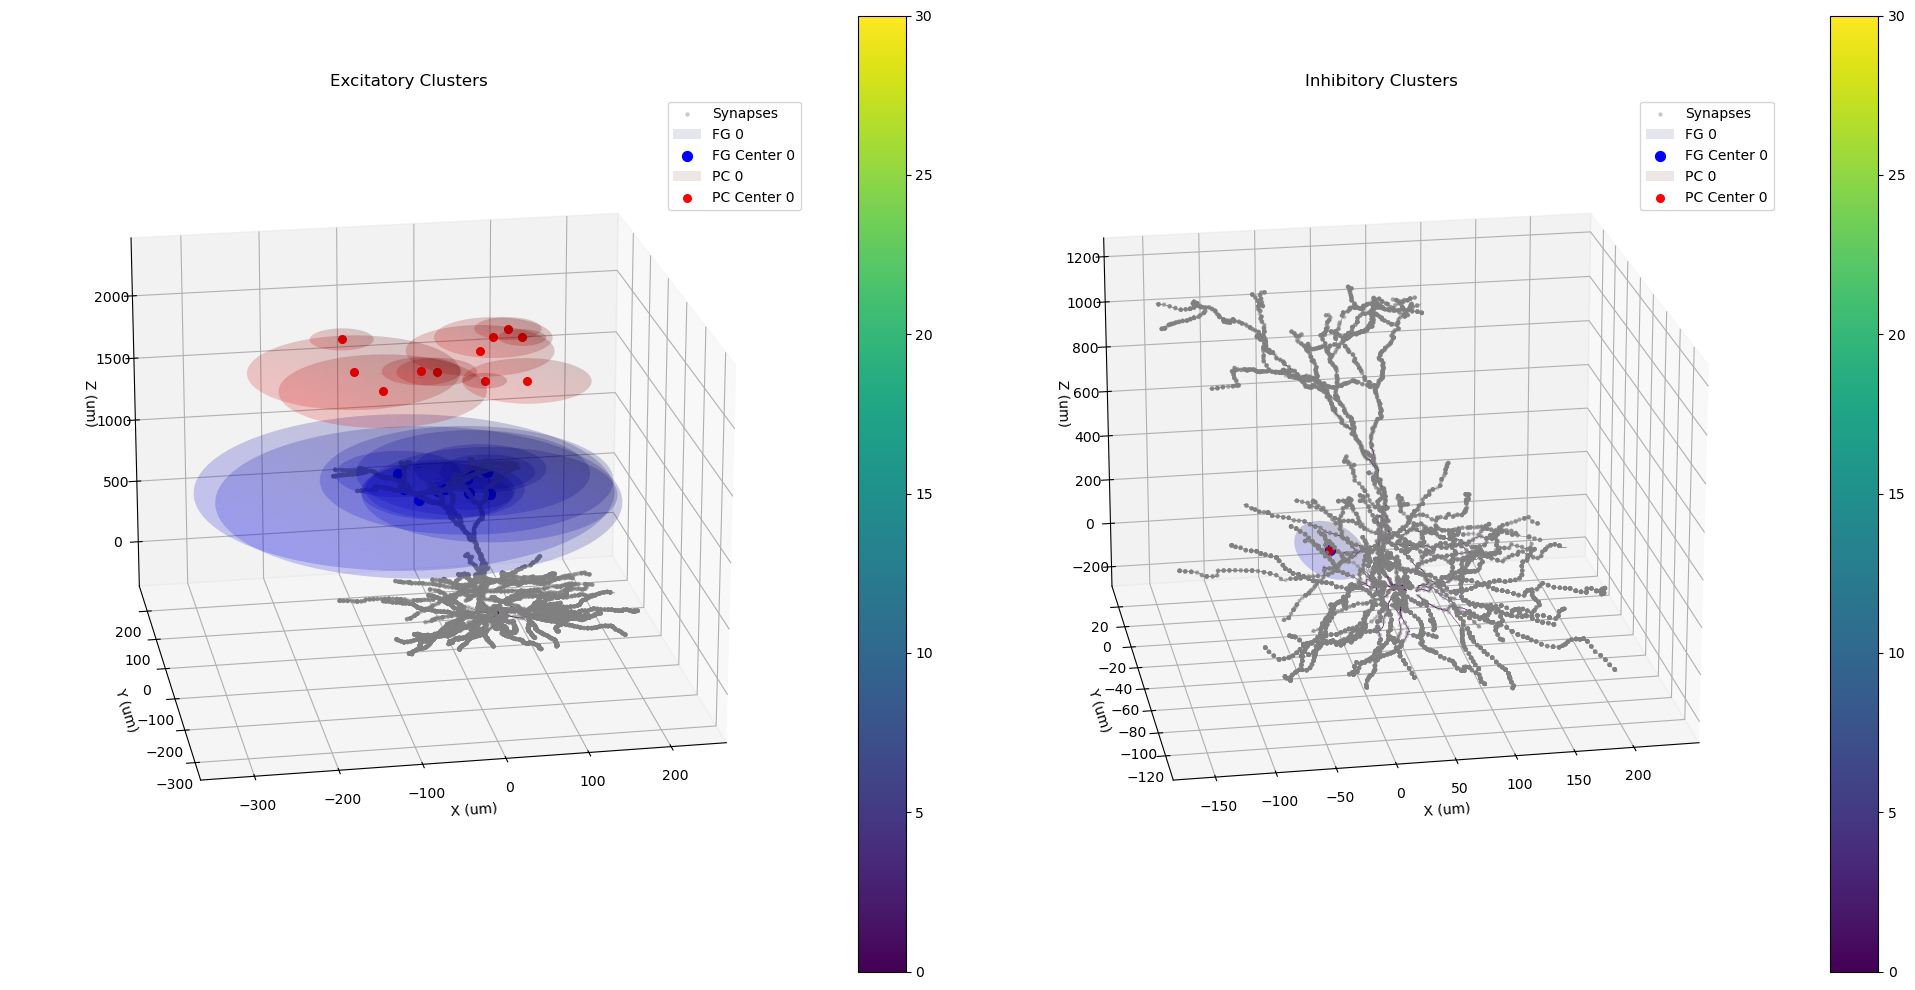

In [17]:
# TODO: move to synapse_analysis.py
# Import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Modules.plot_morphology import plot_clusters
import os
import pickle

# Load parameters and data
# sim_dir = "path_to_your_simulation_directory"  # Replace with your actual simulation directory
with open(os.path.join(sim_dir, "parameters.pickle"), 'rb') as file:
    parameters = pickle.load(file)

# Load segment data
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))

# # Load synapse data if available
synapses_with_seg_info = synapses.merge( # TODO: alternative could be used to save memory.
    seg_data, 
    on='seg_id', 
    how='left',               # carry along all synapses even if a seg_id is missing
    suffixes=('','_seg')      # if both synapses and segments have a column with the same name, suffix the seg col with _seg
)

columns = ['pc_0', 'pc_1', 'pc_2']

# get the coordinates of the synapses
synapse_coords = synapses_with_seg_info[columns].values

# Create figure with multiple subplots for different section types
fig = plt.figure(figsize=(20, 10))

# Plot excitatory clusters
ax1 = fig.add_subplot(121, projection='3d')
plot_clusters(
    seg_data=seg_data,
    clustering_config=parameters.exc_clustering,
    synapse_coords=synapse_coords,
    ax=ax1,
    elevation=20,
    azimuth=-100,
    title='Excitatory Clusters'
)

# Plot inhibitory clusters
ax2 = fig.add_subplot(122, projection='3d')
plot_clusters(
    seg_data=seg_data,
    clustering_config=parameters.inh_clustering,
    synapse_coords=synapse_coords,
    ax=ax2,
    elevation=20,
    azimuth=-100,
    title='Inhibitory Clusters'
)

plt.tight_layout()
plt.show()

# # Optional: Plot individual section types separately
# # exc clusters
# for sec_type in parameters.exc_clustering.keys(): #exc clusters
#     fig = plt.figure(figsize=(10, 10))
#     ax = fig.add_subplot(111, projection='3d')
#     plot_clusters(
#         seg_data=seg_data,
#         clustering_config={sec_type: parameters.exc_clustering[sec_type]},
#         synapse_coords=synapse_coords,
#         ax=ax,
#         elevation=20,
#         azimuth=-100,
#         title=f'Excitatory Clusters - {sec_type}'
#     )
#     plt.tight_layout()
#     plt.show()

# # inh clusters
# for sec_type in parameters.inh_clustering.keys(): # inh clusters
#     fig = plt.figure(figsize=(10, 10))
#     ax = fig.add_subplot(111, projection='3d')
#     plot_clusters(
#         seg_data=seg_data,
#         clustering_config={sec_type: parameters.inh_clustering[sec_type]},
#         synapse_coords=synapse_coords,
#         ax=ax,
#         elevation=20,
#         azimuth=-100,
#         title=f'Inhibitory Clusters - {sec_type}'
#     )
#     plt.tight_layout()
#     plt.show()

Spike raster, etc.

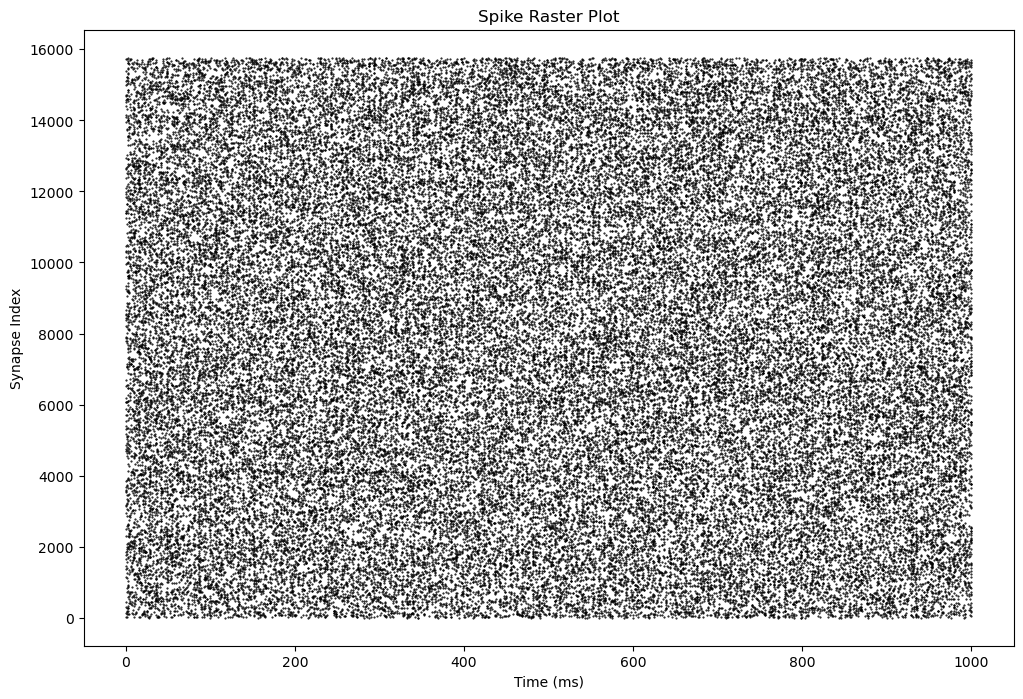

{'total_synapses': 3, 'mean_firing_rate': 6.187067162262011, 'std_firing_rate': 3.2227847742574633, 'mean_weight': 1.5079183855548035, 'std_weight': 0.23215988162174697, 'mean_isi': 53.32258064516129, 'std_isi': 54.37368933836477, 'total_spikes': 94}


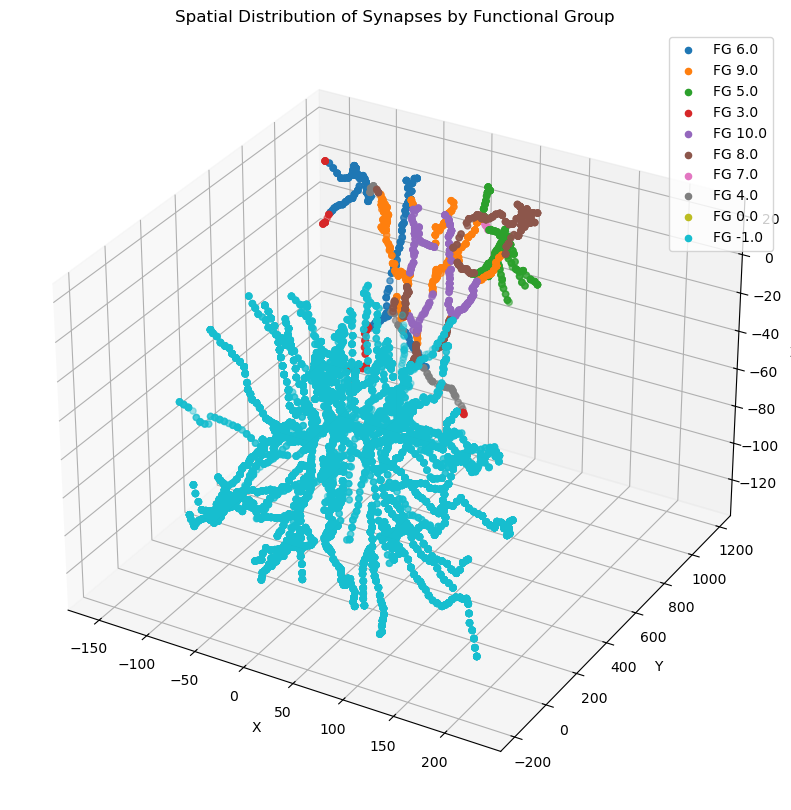

/home/drfrbc/miniconda3/envs/sim_env/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/drfrbc/miniconda3/envs/sim_env/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
from Modules.synapse_analysis import SynapseAnalyzer

    # Generate synapse locations and spike trains for excitatory synapses
# Initialize the analyzer with your simulation directory
analyzer = SynapseAnalyzer(sim_dir)
analyzer.add_segment_data()

# Generate a spike raster plot for excitatory synapses
analyzer.plot_spike_raster(
    synapse_types=['exc'],
    time_window=(0, 1000),  # First second of simulation
    save_path=os.path.join(sim_dir, 'spike_raster.png')
)

# Get statistics for a specific functional group
stats = analyzer.analyze_cluster_statistics(
    functional_group_id=0,
    synapse_type='exc'
)
print(stats)

# Plot the spatial distribution of synapses
analyzer.plot_cluster_spatial_distribution(
    synapse_type='exc',
    save_path=os.path.join(sim_dir, 'spatial_distribution.png')
)

# Analyze correlations between spike trains
analyzer.plot_correlation_matrix(
    synapse_type='exc',
    time_window=(0, 1000),
    save_path=os.path.join(sim_dir, 'correlation_matrix.png')
)

In [ ]:
#TODO: use function that add segment data to synapses.csv via seg_id to fix above error. (should be done in SynapseAnalyzer)

In [ ]:
os.path.abspath(sim_dir) # for copying over